In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import shutil
import os

print("Copying dataset to local SSD...")
src = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba"
dst = "/kaggle/working/celeba/img_align_celeba"

shutil.copytree(src, dst)
print("Done. Files at:", dst)
print("Count:", len(os.listdir(dst + "/img_align_celeba")))

Copying dataset to local SSD...
Done. Files at: /kaggle/working/celeba/img_align_celeba
Count: 202599


### Imports

In [3]:
import os
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import torchvision.utils as vutils

import matplotlib.pyplot as plt

from tqdm import tqdm

In [4]:
print(torch.cuda.is_available())

True


### Model - D & G

In [5]:
class Generator(nn.Module):
    """
        Maps a random noise vector (latent space) -> flattened image.
        z_dim : size of the input noise vector (typically 100)
        img_dim : H * W * C = 32 * 32 * 1 = 1024 for grayscale 32x32
    """

    def __init__(self, z_dim=100, img_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            # block 1: z_dim --> 256
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),

            # block 2: 256 --> 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            # block 3: 512 --> 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(),

            # output: 1024 --> img_dim, squash to [-1, 1]
            nn.Linear(1024, img_dim),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    """
        Maps a flattened image --> scalar probability of being real.
        img_dim : must match Generator's img_dim
    """

    def __init__(self, img_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            # block 1 --> img_dim --> 512
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),

            # block 2: 512 --> 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            # output: 256 --> single logit -- real or fake
            nn.Linear(256, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.net(x)


### Dataset

In [6]:
def get_celeba_loader(
    root: str,
    image_size: int,
    batch_size: int,
    num_workers: int = 0,
    max_samples=20000
) -> DataLoader:
    """
        CelebA Loader
    """
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.Grayscale(num_output_channels=1), # VanillaGAN we will use grayscale only
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # scale to [-1, 1] to match tanh output
    ])

    full_dataset = datasets.ImageFolder(root=root, transform=transform)

    # subset for faster iteration
    indices = random.sample(range(len(full_dataset)), min(max_samples, len(full_dataset)))
    dataset = Subset(full_dataset, indices)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=True,
        pin_memory=False,
        drop_last=True, # avoid batch-size of 1 edge case in BatchNorm
    )

class FakeDataset(Dataset):
    """
        Local mock dataset to avoid downloading full data
        Produces random tensors shaped exactly like real CelebA 32x32 grayscale
    """
    def __init__(
        self, 
        num_samples = 1000,
        image_size = 32,
    ):
        super().__init__()
        self.num_samples = num_samples
        self.image_size = image_size
        
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Shape: (1, H, W), range [-1, 1]
        return torch.randn(1, self.image_size, self.image_size), 0 # 0 = dummy label

def get_fake_loader(batch_size, image_size=32):
    dataset = FakeDataset(num_samples=1000, image_size=image_size)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)


### Utils - Plotting

In [7]:
def save_image_grid(fake_samples, epoch, path="outputs/"):
    """
        Saves a grid of generated images to disk.
        fake_samples: (B, 1, H, W) tensor in [-1, 1]
    """

    os.makedirs(path, exist_ok=True)

    # denormalise for display
    fake_samples = (fake_samples + 1) / 2

    grid = vutils.make_grid(fake_samples, nrow=8, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(grid_np.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Epoch {epoch}")
    plt.tight_layout()
    plt.savefig(os.path.join(path, f"epoch_{epoch:03d}.png"), dpi=100)
    plt.close()

def plot_loss_curve(loss_G, loss_D, path="outputs/"):
    """
        Saves G and D loss curves across epochs.
    """
    os.makedirs(path, exist_ok=True)

    plt.figure(figsize=(10, 4))
    plt.plot(loss_G, label="Generator Loss", color="steelblue")
    plt.plot(loss_D, label="Discriminator Loss", color="tomato")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(path, "loss_curve.png"), dpi=100)
    plt.close()

def load_and_display_progression(output_dir, epochs):
    """
        Notebook-only function.
        Loads saved grids from disk and plots them side by side for visual progression.
        epochs: e.g. [1, 5, 10, 25, 50]
    """
    fig, axes = plt.subplots(1, len(epochs), figsize=(4 * len(epochs), 4))

    for ax, epoch in zip(axes, epochs):
        img_path = os.path.join(output_dir, f"epoch_{epoch:03d}.png")
        img = plt.imread(img_path)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.suptitle("GAN Progression", fontsize=14)
    plt.tight_layout()
    plt.show()


### Train

In [8]:
# hyperparameters
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR = 2e-4
BATCH_SIZE = 128
Z_DIM = 100
IMAGE_DIM = 32 * 32 * 1 # 1024 - 32x32 grayscale
NUM_EPOCHS = 50
SAVE_EPOCHS = [1, 5, 10, 25, 50] # saving image grids to view the learning of G
IS_KAGGLE = torch.cuda.is_available()

def train():
    # data
    if IS_KAGGLE:
        loader = get_celeba_loader(
            root="/kaggle/working/celeba/img_align_celeba",
            image_size=32,
            batch_size=BATCH_SIZE
        )

    else:
        loader = get_fake_loader(
            batch_size=BATCH_SIZE,
            image_size=32
        )

    # models
    D = Discriminator(img_dim=IMAGE_DIM).to(DEVICE)
    G = Generator(z_dim=Z_DIM, img_dim=IMAGE_DIM).to(DEVICE)

    # loss + optims
    criterion = nn.BCELoss()
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
    # betas=(0.5, 0.999) is GAN standard (experimentally proven) - 0.9 causes oscillation

    # fixed noise: same vector every save -> comparable grids across epochs
    fixed_noise = torch.randn(64, Z_DIM).to(DEVICE)

    loss_G_history = []
    loss_D_history = []

    # training
    print("--------------- Starting training ---------------")

    for epoch in range(1, NUM_EPOCHS + 1):
        loss_G_epoch = 0.0
        loss_D_epoch = 0.0

        for batch_idx, (real, _) in enumerate(tqdm(loader, desc=f"Epoch [{epoch}/{NUM_EPOCHS}]", leave=True)):

            real = real.view(real.size(0), -1).to(DEVICE) # flatten: (B, 1, 32, 32) --> (B, 1024)
            B = real.size(0)

            # train D
            """
                1. Get real img from datalaoder
                2. Generate fake images (G, no grad)
                3. D forward pass on real --> loss_real
                4. D forward pass on fake --> loss_fake
                5. loss_D = loss_real + loss_fake
                6. Backprop + wt update
            """
            noise = torch.randn(B, Z_DIM).to(DEVICE)
            fake = G(noise).detach() # no G gradients here

            real_labels = torch.ones(B, 1).to(DEVICE)
            fake_labels = torch.zeros(B, 1).to(DEVICE)

            loss_D_real = criterion(D(real), real_labels)
            loss_D_fake = criterion(D(fake), fake_labels)
            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # train G
            """
                1. Generate NEW fake images (fresh noise)
                2. D forward pass on fake (no D grad update)
                3. loss_G = how badly D was fooled
                4. backprop and wtt update
            """
            noise = torch.randn(B, Z_DIM).to(DEVICE)
            fake = G(noise)

            # G wants D to output 1 (real) for its fakes
            loss_G = criterion(D(fake), real_labels)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            loss_G_epoch += loss_G.item()
            loss_D_epoch += loss_D.item()

        # end of epoch
        avg_G = loss_G_epoch / len(loader)
        avg_D = loss_D_epoch / len(loader)
        loss_G_history.append(avg_G)
        loss_D_history.append(avg_D)

        print(f"Epoch [{epoch}/{NUM_EPOCHS}] | loss_D: {avg_D:.4f} | loss_G: {avg_G:.4f}")

        if epoch in SAVE_EPOCHS:
            with torch.no_grad():
                sample = G(fixed_noise) # (64, 1024)
                sample = sample.view(-1, 1, 32, 32) # reshape for grid
                save_image_grid(sample, epoch, path="outputs/")

    plot_loss_curve(loss_G_history, loss_D_history, path="outputs/")



# calling train
train()

--------------- Starting training ---------------


Epoch [1/50]: 100%|██████████| 156/156 [00:29<00:00,  5.24it/s]


Epoch [1/50] | loss_D: 1.0097 | loss_G: 0.8582


Epoch [2/50]: 100%|██████████| 156/156 [00:28<00:00,  5.40it/s]


Epoch [2/50] | loss_D: 0.8754 | loss_G: 1.3671


...

Epoch [48/50] | loss_D: 1.2793 | loss_G: 0.9854


Epoch [49/50]: 100%|██████████| 156/156 [00:20<00:00,  7.54it/s]


Epoch [49/50] | loss_D: 1.2870 | loss_G: 0.9591


Epoch [50/50]: 100%|██████████| 156/156 [00:20<00:00,  7.49it/s]


Epoch [50/50] | loss_D: 1.3213 | loss_G: 0.9329


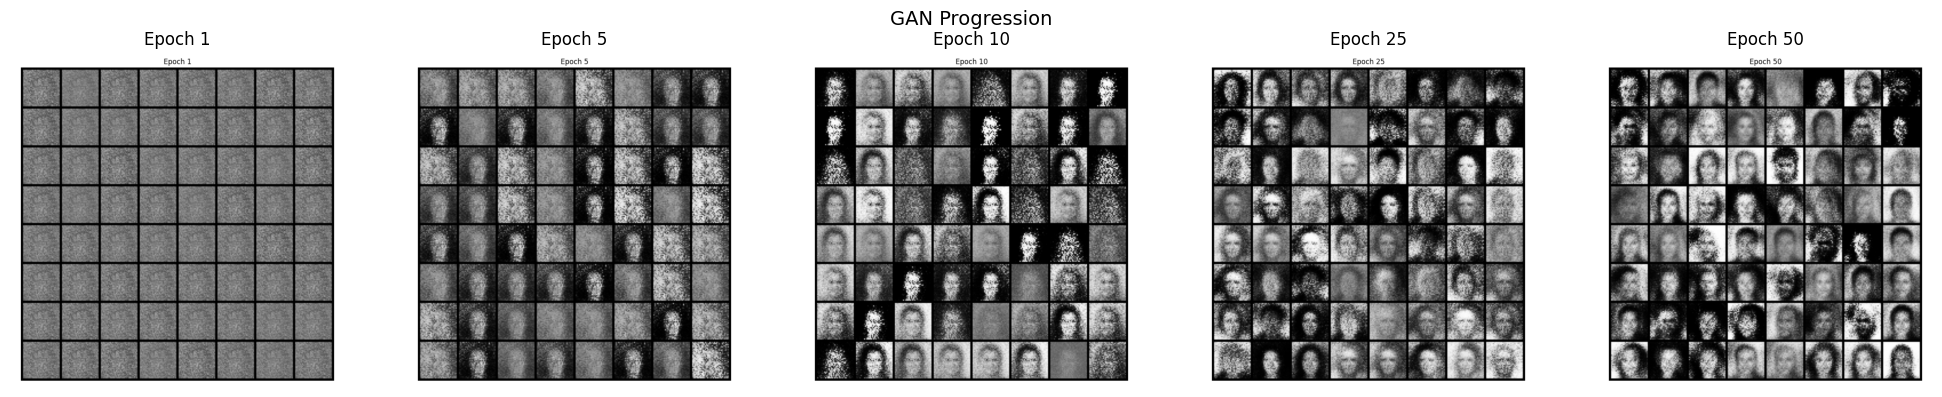

In [9]:
load_and_display_progression(output_dir='/kaggle/working/outputs', epochs=[1, 5, 10, 25, 50])

### Observations

1. **Epoch 1:** - Pure noise. G has no idea what a face is yet.
2. **Epoch 5:** - Blobs emerging. G has learned that faces have a roughly centered bright region. No structure yet.
3. **Epoch 10:** - Recognizable faces. Eyes, nose placement, oval face shape — all there. ***This is where the MLP hits its ceiling***.
4. **Epoch 25 to 50** - Lil bit improvement. Some faces sharper, but the grid still has blurry. The MLP cannot model spatial structure — every pixel is independent in its representation.

> That blurriness and inconsistency at epoch 50 is not a training failure. That is exactly the Vanilla GAN ceiling. `DCGAN` is meant to improve exactly that.

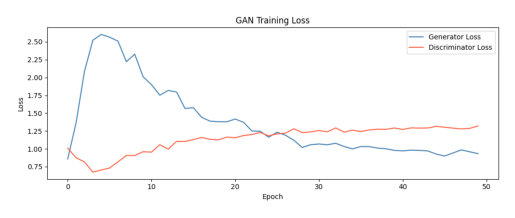

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/working/outputs/loss_curve.png')
plt.imshow(img)
plt.axis('off') # Optional: hides grid lines and pixel counts
plt.show()

### Observations

The loss curve looks good and healthy

- loss_G spikes early (epoch 1-5) -- D is easily beating G initially
- Both losses converge towards equilibrium around epoch 20-25
- After epoch 25 they saturate -- **loss_D ~1.3**, **loss_G ~1.0**

loss_D hovering around 1.3 means D is uncertain but slightly favoring real. \
loss_G around 1.0 means G is genuinely fooling D roughly half the time. \
**This is the Nash equillibrium for BCE loss -- both are stuck, neither can improve further.** 
> This architecture is at the bottleneck